# Understanding Probability Distributions

A **probability distribution** describes how probability is spread across the possible values of a random variable.

| Concept | Discrete | Continuous |
|---|---|---|
| Function name | Probability Mass Function (PMF) | Probability Density Function (PDF) |
| Probability at a point | P(X = x) = p(x) | Always zero — use intervals |
| Probability of an interval | Sum over values | Area under the curve |
| Sums/integrates to | 1 | 1 |

**Key related functions:**

| Function | Symbol | Definition |
|---|---|---|
| PDF / PMF | f(x) | Density or mass at x |
| CDF | F(x) | P(X ≤ x) |
| Percent Point Function (PPF) | G(α) | Inverse CDF — x such that P(X ≤ x) = α |
| Survival Function | S(x) | P(X > x) = 1 − F(x) |
| Hazard Function | h(x) | f(x) / S(x) — instantaneous failure rate |
| Cumulative Hazard | H(x) | −ln(S(x)) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

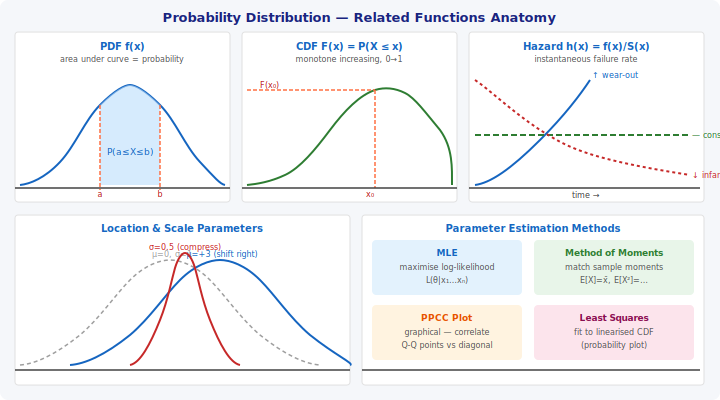

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="400"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="400" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="13" font-weight="bold"
        fill="#1A237E">Probability Distribution — Related Functions Anatomy</text>

  <!-- PDF panel -->
  <rect x="15" y="32" width="215" height="170" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="122" y="50" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">PDF  f(x)</text>
  <text x="122" y="62" text-anchor="middle" font-size="8" fill="#555">area under curve = probability</text>
  <!-- Bell curve -->
  <path d="M 20,185 C 30,184 45,178 60,162 C 75,146 85,120 100,105
           C 115,90 125,85 130,85 C 135,85 145,90 160,105
           C 175,120 185,146 200,162 C 215,178 220,184 225,185"
        fill="none" stroke="#1565C0" stroke-width="2"/>
  <!-- Shaded area a to b -->
  <path d="M 100,185 L 100,105 C 115,90 125,85 130,85 C 135,85 145,90 160,105 L 160,185 Z"
        fill="#BBDEFB" opacity="0.6"/>
  <line x1="100" y1="105" x2="100" y2="190" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="4,2"/>
  <line x1="160" y1="105" x2="160" y2="190" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="4,2"/>
  <text x="100" y="197" text-anchor="middle" font-size="8" fill="#B71C1C">a</text>
  <text x="160" y="197" text-anchor="middle" font-size="8" fill="#B71C1C">b</text>
  <text x="130" y="155" text-anchor="middle" font-size="9" fill="#1565C0">P(a≤X≤b)</text>
  <line x1="15" y1="188" x2="230" y2="188" stroke="#424242" stroke-width="1.5"/>

  <!-- CDF panel -->
  <rect x="242" y="32" width="215" height="170" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="349" y="50" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">CDF  F(x) = P(X ≤ x)</text>
  <text x="349" y="62" text-anchor="middle" font-size="8" fill="#555">monotone increasing, 0→1</text>
  <!-- S-curve -->
  <path d="M 247,185 C 257,184 270,182 285,175 C 300,168 315,150 330,130
           C 345,110 360,95 375,90 C 385,87 395,88 405,93
           C 415,98 425,112 440,130 C 453,148 452,168 452,185"
        fill="none" stroke="#2E7D32" stroke-width="2"/>
  <!-- x0 annotation -->
  <line x1="375" y1="90" x2="375" y2="188" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="4,2"/>
  <line x1="247" y1="90" x2="375" y2="90" stroke="#FF7043" stroke-width="1.5" stroke-dasharray="4,2"/>
  <text x="370" y="197" text-anchor="middle" font-size="8" fill="#B71C1C">x₀</text>
  <text x="260" y="88" font-size="8" fill="#B71C1C">F(x₀)</text>
  <line x1="242" y1="188" x2="457" y2="188" stroke="#424242" stroke-width="1.5"/>

  <!-- Hazard panel -->
  <rect x="469" y="32" width="235" height="170" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="586" y="50" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Hazard  h(x) = f(x)/S(x)</text>
  <text x="586" y="62" text-anchor="middle" font-size="8" fill="#555">instantaneous failure rate</text>
  <!-- Three hazard shapes -->
  <!-- Increasing (Weibull β>1) -->
  <path d="M 475,185 C 490,183 510,170 540,140 C 565,115 580,95 590,80"
        fill="none" stroke="#1565C0" stroke-width="2"/>
  <text x="592" y="78" font-size="8" fill="#1565C0">↑ wear-out</text>
  <!-- Constant (Exponential) -->
  <path d="M 475,135 L 690,135" fill="none" stroke="#2E7D32" stroke-width="2" stroke-dasharray="6,3"/>
  <text x="692" y="138" font-size="8" fill="#2E7D32">— constant</text>
  <!-- Decreasing (β<1) -->
  <path d="M 475,80 C 490,90 510,110 540,130 C 565,145 580,158 690,175"
        fill="none" stroke="#C62828" stroke-width="2" stroke-dasharray="3,3"/>
  <text x="692" y="178" font-size="8" fill="#C62828">↓ infant mort.</text>
  <line x1="469" y1="188" x2="700" y2="188" stroke="#424242" stroke-width="1.5"/>
  <text x="586" y="198" text-anchor="middle" font-size="8" fill="#424242">time →</text>

  <!-- Location/Scale panel -->
  <rect x="15" y="215" width="335" height="170" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="182" y="232" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Location &amp; Scale Parameters</text>
  <!-- Standard curve -->
  <path d="M 20,365 C 35,364 55,355 80,335 C 100,318 115,295 130,280
           C 145,265 160,260 170,260 C 180,260 195,265 210,280
           C 225,295 240,318 260,335 C 285,355 305,364 320,365"
        fill="none" stroke="#9E9E9E" stroke-width="1.5" stroke-dasharray="4,3"/>
  <text x="172" y="257" text-anchor="middle" font-size="8" fill="#9E9E9E">μ=0, σ=1</text>
  <!-- Location shifted (right) -->
  <path d="M 70,365 C 85,364 105,355 130,335 C 150,318 165,295 180,280
           C 195,265 210,260 220,260 C 230,260 245,265 260,280
           C 275,295 290,318 310,335 C 335,355 355,364 350,365"
        fill="none" stroke="#1565C0" stroke-width="2"/>
  <text x="222" y="257" text-anchor="middle" font-size="8" fill="#1565C0">μ=+3 (shift right)</text>
  <!-- Scale compressed (tall narrow) -->
  <path d="M 130,365 C 140,363 150,345 160,320 C 168,300 172,278 175,268
           C 178,258 182,253 185,253 C 188,253 192,258 195,268
           C 198,278 202,300 210,320 C 220,345 230,363 240,365"
        fill="none" stroke="#C62828" stroke-width="2"/>
  <text x="185" y="250" text-anchor="middle" font-size="8" fill="#C62828">σ=0.5 (compress)</text>
  <line x1="15" y1="370" x2="350" y2="370" stroke="#424242" stroke-width="1.5"/>

  <!-- Estimation panel -->
  <rect x="362" y="215" width="342" height="170" fill="white" stroke="#E0E0E0" rx="3"/>
  <text x="533" y="232" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Parameter Estimation Methods</text>
  <!-- MLE box -->
  <rect x="372" y="240" width="150" height="55" fill="#E3F2FD" rx="4"/>
  <text x="447" y="256" text-anchor="middle" font-size="9" font-weight="bold" fill="#1565C0">MLE</text>
  <text x="447" y="270" text-anchor="middle" font-size="8" fill="#555">maximise log-likelihood</text>
  <text x="447" y="283" text-anchor="middle" font-size="8" fill="#555">L(θ|x₁…xₙ)</text>
  <!-- MOM box -->
  <rect x="534" y="240" width="160" height="55" fill="#E8F5E9" rx="4"/>
  <text x="614" y="256" text-anchor="middle" font-size="9" font-weight="bold" fill="#2E7D32">Method of Moments</text>
  <text x="614" y="270" text-anchor="middle" font-size="8" fill="#555">match sample moments</text>
  <text x="614" y="283" text-anchor="middle" font-size="8" fill="#555">E[X]=x̄, E[X²]=…</text>
  <!-- PPCC box -->
  <rect x="372" y="305" width="150" height="55" fill="#FFF3E0" rx="4"/>
  <text x="447" y="321" text-anchor="middle" font-size="9" font-weight="bold" fill="#E65100">PPCC Plot</text>
  <text x="447" y="335" text-anchor="middle" font-size="8" fill="#555">graphical — correlate</text>
  <text x="447" y="348" text-anchor="middle" font-size="8" fill="#555">Q-Q points vs diagonal</text>
  <!-- Least Squares box -->
  <rect x="534" y="305" width="160" height="55" fill="#FCE4EC" rx="4"/>
  <text x="614" y="321" text-anchor="middle" font-size="9" font-weight="bold" fill="#880E4F">Least Squares</text>
  <text x="614" y="335" text-anchor="middle" font-size="8" fill="#555">fit to linearised CDF</text>
  <text x="614" y="348" text-anchor="middle" font-size="8" fill="#555">(probability plot)</text>
  <line x1="362" y1="370" x2="700" y2="370" stroke="#424242" stroke-width="1.5"/>
</svg>
"""
display(SVG(_svg))

## Related Probability Functions

Given a continuous distribution with PDF f(x):

| Function | Formula | Key property |
|---|---|---|
| CDF | F(x) = ∫₋∞ˣ f(t) dt | Monotone ↑, range [0,1] |
| PPF (quantile) | G(α) = F⁻¹(α) | Inverse of CDF |
| Survival | S(x) = 1 − F(x) | P(X > x) |
| Inverse survival | Z(α) = G(1−α) | |
| Hazard | h(x) = f(x)/S(x) | Instantaneous failure rate |
| Cumulative hazard | H(x) = −ln S(x) | H(x) = ∫₀ˣ h(t) dt |

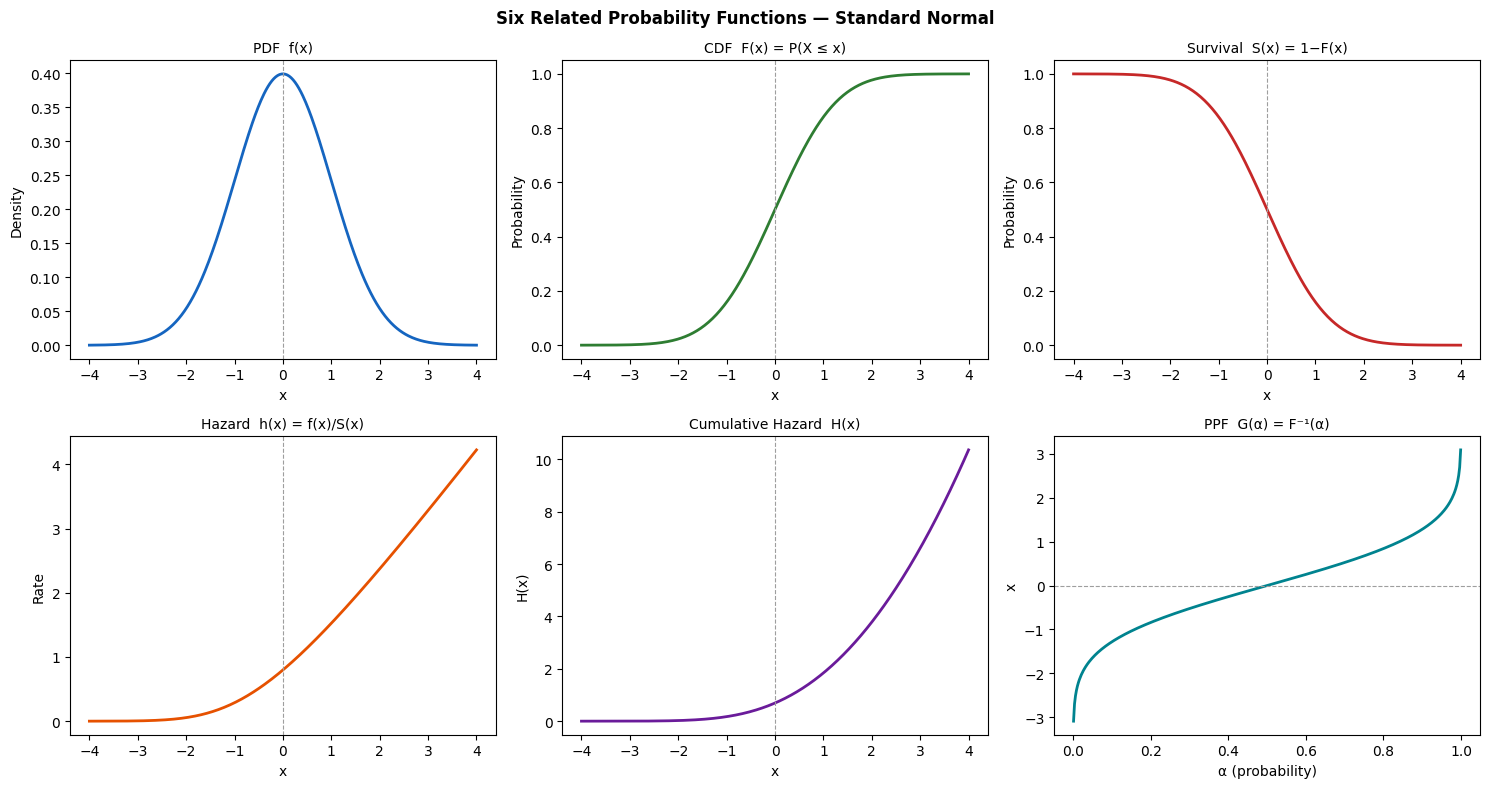

In [3]:
# Demonstrate all 6 related functions for the standard normal
dist = stats.norm(loc=0, scale=1)
x = np.linspace(-4, 4, 400)

pdf  = dist.pdf(x)
cdf  = dist.cdf(x)
sf   = dist.sf(x)          # survival = 1 - CDF
haz  = pdf / sf            # hazard
chaz = -np.log(sf)         # cumulative hazard

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Six Related Probability Functions — Standard Normal', fontsize=12, fontweight='bold')

plots = [
    (axes[0,0], pdf,  'PDF  f(x)',               '#1565C0', 'Density'),
    (axes[0,1], cdf,  'CDF  F(x) = P(X ≤ x)',    '#2E7D32', 'Probability'),
    (axes[0,2], sf,   'Survival  S(x) = 1−F(x)', '#C62828', 'Probability'),
    (axes[1,0], haz,  'Hazard  h(x) = f(x)/S(x)','#E65100', 'Rate'),
    (axes[1,1], chaz, 'Cumulative Hazard  H(x)',  '#6A1B9A', 'H(x)'),
]
for ax, y, title, color, ylabel in plots:
    ax.plot(x, y, color=color, linewidth=2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel(ylabel)
    ax.axvline(0, color='#9E9E9E', linewidth=0.8, linestyle='--')

# PPF — plot quantile function (inverse CDF)
ax = axes[1,2]
alpha = np.linspace(0.001, 0.999, 400)
ppf   = dist.ppf(alpha)
ax.plot(alpha, ppf, color='#00838F', linewidth=2)
ax.set_title('PPF  G(α) = F⁻¹(α)', fontsize=10)
ax.set_xlabel('α (probability)'); ax.set_ylabel('x')
ax.axhline(0, color='#9E9E9E', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

## Location and Scale Parameters

Any distribution defined in **standard form** (location=0, scale=1) can be shifted and stretched:

| Parameter | Effect | Standard → General |
|---|---|---|
| Location μ | Shifts the distribution left/right | f(x) → f(x − μ) |
| Scale σ | Stretches (σ>1) or compresses (σ<1) | f(x) → (1/σ) f((x−μ)/σ) |

Equivalently: if Y ~ Standard, then X = μ + σY ~ General(μ, σ)

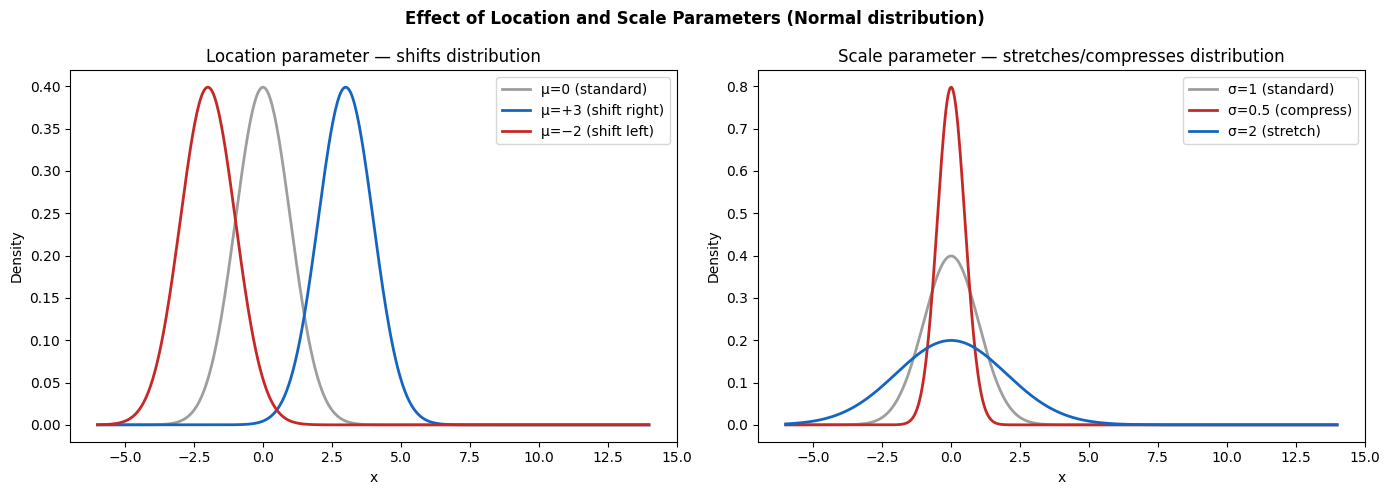

In [4]:
x = np.linspace(-6, 14, 500)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Location and Scale Parameters (Normal distribution)', fontsize=12, fontweight='bold')

# Location shifts
ax = axes[0]
for mu, color, label in [(0, '#9E9E9E', 'μ=0 (standard)'),
                          (3, '#1565C0', 'μ=+3 (shift right)'),
                          (-2, '#C62828', 'μ=−2 (shift left)')]:
    ax.plot(x, stats.norm(loc=mu, scale=1).pdf(x), color=color, linewidth=2, label=label)
ax.set_title('Location parameter — shifts distribution')
ax.set_xlabel('x'); ax.set_ylabel('Density')
ax.legend()

# Scale stretches/compresses
ax = axes[1]
for sigma, color, label in [(1,   '#9E9E9E', 'σ=1 (standard)'),
                              (0.5, '#C62828', 'σ=0.5 (compress)'),
                              (2,   '#1565C0', 'σ=2 (stretch)')]:
    ax.plot(x, stats.norm(loc=0, scale=sigma).pdf(x), color=color, linewidth=2, label=label)
ax.set_title('Scale parameter — stretches/compresses distribution')
ax.set_xlabel('x'); ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

## Estimating Parameters

| Method | How | When to use |
|---|---|---|
| **MLE** | Maximise log-likelihood L(θ\|data) | General purpose — asymptotically efficient |
| **Method of Moments** | Equate sample moments (mean, variance) to theoretical | Simple closed-form distributions |
| **Least Squares** | Fit linearised CDF on probability plot | Useful for Weibull, Extreme Value |
| **PPCC Plot** | Scan shape parameters; pick the one maximising Q-Q correlation | Selecting within a family |

True parameters:  a=2.00, scale=3.00
MLE estimates:    a=2.48, scale=2.40
MOM estimates:    a=2.44, scale=2.44


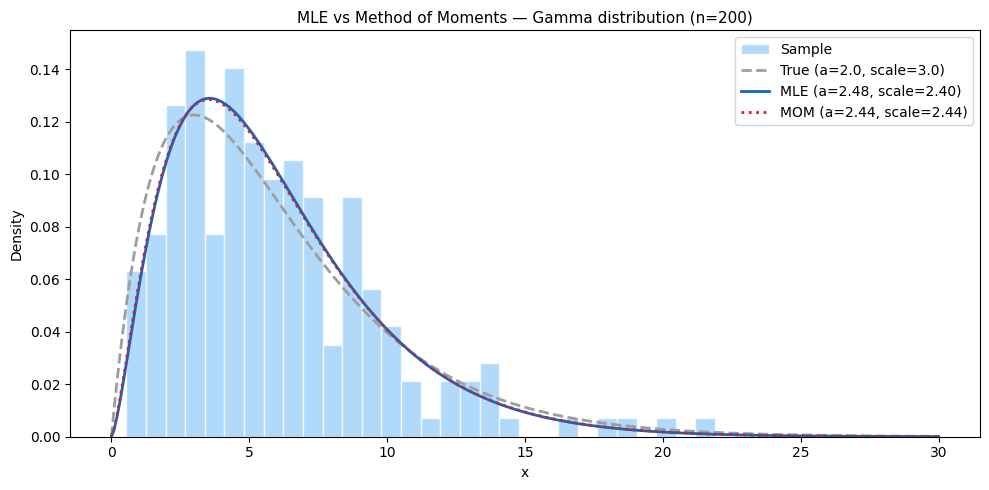

In [5]:
np.random.seed(42)

# Generate data from Gamma(a=2, scale=3) — unknown parameters
true_a, true_scale = 2.0, 3.0
data = stats.gamma.rvs(a=true_a, scale=true_scale, size=200)

# MLE
a_mle, loc_mle, scale_mle = stats.gamma.fit(data, floc=0)

# Method of Moments (Gamma: mean=a*scale, var=a*scale²)
m1 = data.mean()
m2 = data.var()
scale_mom = m2 / m1
a_mom = m1 / scale_mom

print(f"True parameters:  a={true_a:.2f}, scale={true_scale:.2f}")
print(f"MLE estimates:    a={a_mle:.2f}, scale={scale_mle:.2f}")
print(f"MOM estimates:    a={a_mom:.2f}, scale={scale_mom:.2f}")

x = np.linspace(0, 30, 300)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data, bins=30, density=True, color='#90CAF9', edgecolor='white', alpha=0.7, label='Sample')
ax.plot(x, stats.gamma.pdf(x, a=true_a, scale=true_scale),
        color='#9E9E9E', linewidth=2, linestyle='--', label=f'True (a={true_a}, scale={true_scale})')
ax.plot(x, stats.gamma.pdf(x, a=a_mle, scale=scale_mle),
        color='#1565C0', linewidth=2, label=f'MLE (a={a_mle:.2f}, scale={scale_mle:.2f})')
ax.plot(x, stats.gamma.pdf(x, a=a_mom, scale=scale_mom),
        color='#C62828', linewidth=2, linestyle=':', label=f'MOM (a={a_mom:.2f}, scale={scale_mom:.2f})')
ax.set_title('MLE vs Method of Moments — Gamma distribution (n=200)', fontsize=11)
ax.set_xlabel('x'); ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **PMF vs PDF** | Discrete: P(X=x) > 0; Continuous: P(X=x) = 0 — always use intervals |
| **CDF** | The primary summary — fully characterises the distribution |
| **PPF** | Inverse CDF — used for computing confidence intervals and critical values |
| **Hazard function** | Rising = wear-out failure; Constant = random failure; Falling = infant mortality |
| **Location** | Shifts the distribution — changes the mean, not the shape |
| **Scale** | Stretches/compresses — changes spread, not shape |
| **Shape** | Changes the fundamental form of the distribution (e.g., skewness, tail weight) |
| **MLE** | Preferred for large samples — asymptotically efficient and unbiased |
| **MOM** | Simple and fast — may be less efficient but useful for quick estimates |
| **PPCC** | Graphical method — scan shape parameter and pick the value with highest Q-Q correlation |